# Анализ временных рядов

## Временные ряды

Перед вами данные американской энергетической компании PJM East. В файле `energy_consumption.csv` указано, сколько электроэнергии потребляют её клиенты.

Рассмотрим столбцы таблицы:

* `Datetime` (англ. «дата-время») — значение даты и времени на временной оси. Переменная называется так же, как и тип данных datetime. В этой таблице интервал равен одному часу.
* `PJME_MW` (название компании и MW; англ. megawatt, «мегаватт») — расход электроэнергии за час.

Нужно привести данные к удобному формату,
для их анализа выделить временной промежуток,
а затем построить график временного ряда.
В этом поможет документация Pandas.

1.
Измените тип данных `Datetime` с `object` на `datetime64`.
Но прежде запустите код и просмотрите общую информацию о данных.

В документации Pandas выберите любой способ преобразования данных.
Формат вывода даты указывать не нужно: библиотека определит его самостоятельно.

Напечатайте на экране информацию о таблице (уже в прекоде).

In [1]:
import pandas as pd

data = pd.read_csv('https://code.s3.yandex.net/datasets/energy_consumption.csv')
data['Datetime'] = pd.to_datetime(data['Datetime'])
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145366 entries, 0 to 145365
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   Datetime  145366 non-null  datetime64[ns]
 1   PJME_MW   145366 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 2.2 MB


2.
Установите индекс таблицы равным столбцу `Datetime`.
В документации Pandas выберите любой способ установки индекса.

Напечатайте на экране информацию о таблице (уже в прекоде).

In [2]:
data = data.set_index('Datetime')
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 145366 entries, 2002-12-31 01:00:00 to 2018-01-02 00:00:00
Data columns (total 1 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   PJME_MW  145366 non-null  float64
dtypes: float64(1)
memory usage: 2.2 MB


3.
Чтобы проверить, в хронологическом ли порядке расположены даты и время, посмотрите атрибут индекса таблицы `is_monotonic` (англ. «монотонный»). Если порядок соблюдён, атрибут вернёт `True`, если нет — `False`.

Отсортируйте индекс таблицы. Метод найдите в документации.

Напечатайте на экране значение атрибута `is_monotonic` (уже в прекоде).
Затем вызовом функции `info()` выведите на экран общую информацию о таблице.

In [3]:
data.index.is_monotonic_increasing

False

In [4]:
data = data.sort_index()
print(data.index.is_monotonic_increasing)
data.info()

True
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 145366 entries, 2002-01-01 01:00:00 to 2018-08-03 00:00:00
Data columns (total 1 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   PJME_MW  145366 non-null  float64
dtypes: float64(1)
memory usage: 2.2 MB


4.
Из временного ряда выделите данные с января по июнь 2018 года.

Даты во временных рядах можно указывать в срезах.
В прекоде выбраны значения с 2016 по 2017 год включительно.

Напечатайте на экране информацию о таблице (уже в прекоде).

In [5]:
data = data['2018-01':'2018-06']
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4343 entries, 2018-01-01 00:00:00 to 2018-06-30 23:00:00
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   PJME_MW  4343 non-null   float64
dtypes: float64(1)
memory usage: 67.9 KB


5.
Постройте график временного ряда.

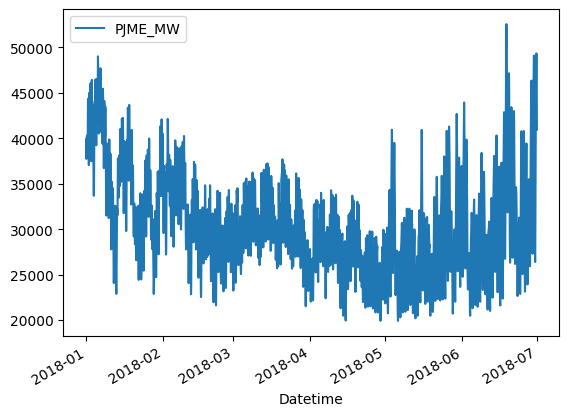

In [6]:
import matplotlib.pyplot as plt

data.plot()
plt.show()

## Ресемплирование

1.
Постройте график среднего потребления электроэнергии по годам.

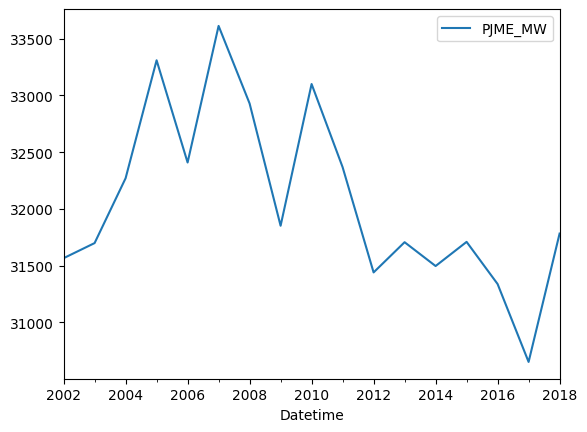

In [7]:
data_y = pd.read_csv('https://code.s3.yandex.net/datasets/energy_consumption.csv',
                     index_col=[0], parse_dates=[0])
data_y.resample('YE').mean().plot()
plt.show()

2.
Постройте график энергопотребления с января по июнь 2018 года.
Выберите интервал в один день, по каждому — вычислите суммарное энергопотребление.

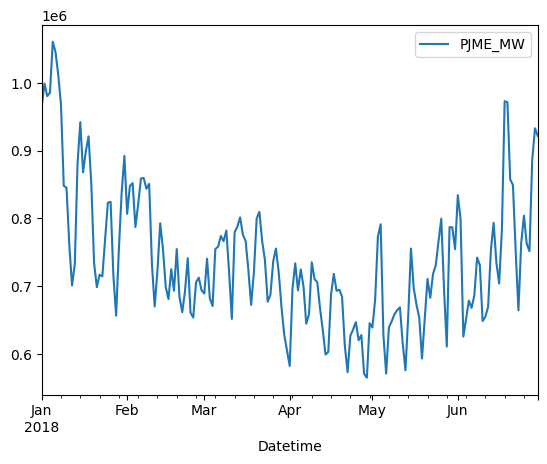

In [8]:
data.resample('1D').sum().plot()
plt.show()

## Скользящее среднее

Добавьте в столбец `rolling_mean` скользящее среднее с размером окна, равным `10`.
Выведите на экран графики энергопотребления с января по июнь 2018 года и скользящего среднего (уже в прекоде).

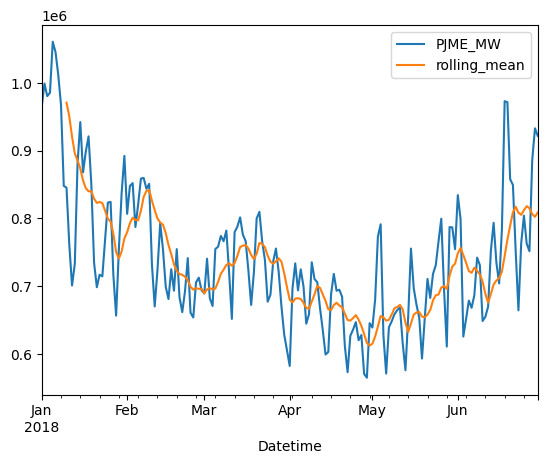

In [9]:
data = data.resample('1D').sum()
data['rolling_mean'] = data['PJME_MW'].rolling(10).mean()
data.plot()
plt.show()

## Тренды и сезонность

1.
Разложите временной ряд на тренд и сезонную компоненту.
Допишите код вывода графиков этих составляющих ряда.

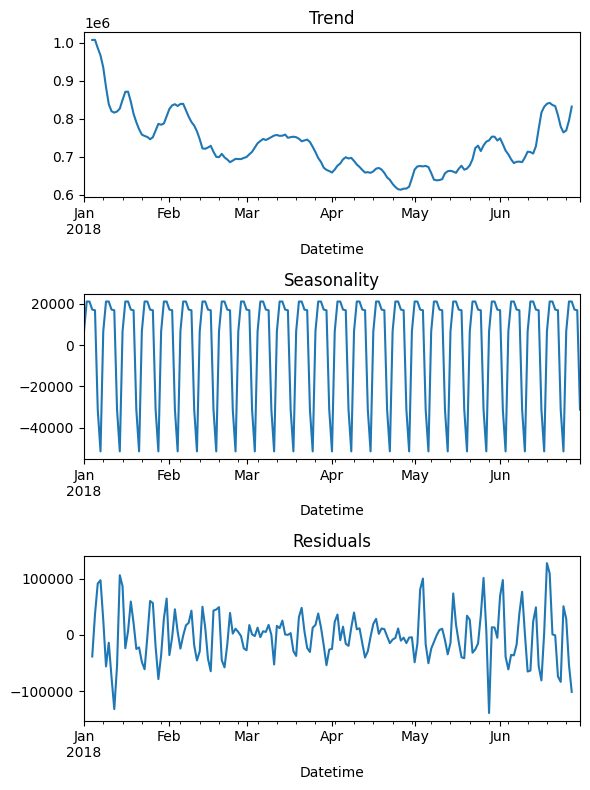

In [10]:
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

data = pd.read_csv('https://code.s3.yandex.net/datasets/energy_consumption.csv', index_col=[0], parse_dates=[0])
data.sort_index(inplace=True)
data = data['2018-01':'2018-06'].resample('1D').sum()

decomposed = seasonal_decompose(data)

plt.figure(figsize=(6, 8))
plt.subplot(311)
decomposed.trend.plot(ax=plt.gca())
plt.title('Trend')
plt.subplot(312)
decomposed.seasonal.plot(ax=plt.gca())
plt.title('Seasonality')
plt.subplot(313)
decomposed.resid.plot(ax=plt.gca())
plt.title('Residuals')
plt.tight_layout()

2.
Постройте график сезонной составляющей за первые 15 дней января 2018 года.

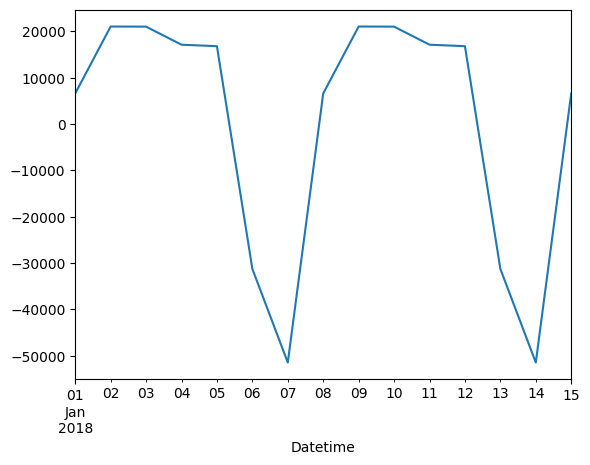

In [11]:
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

data = pd.read_csv('https://code.s3.yandex.net/datasets/energy_consumption.csv', index_col=[0], parse_dates=[0])
data.sort_index(inplace=True)
data = data['2018-01':'2018-06'].resample('1D').sum()

decomposed = seasonal_decompose(data)

decomposed.seasonal['2018-01-01':'2018-01-15'].plot()
plt.show()

## Разности временного ряда

Вычислите разности временного ряда.
Пропущенные значения заполнять не нужно.

На графике изобразите скользящее среднее и скользящее стандартное отклонение (уже в прекоде).

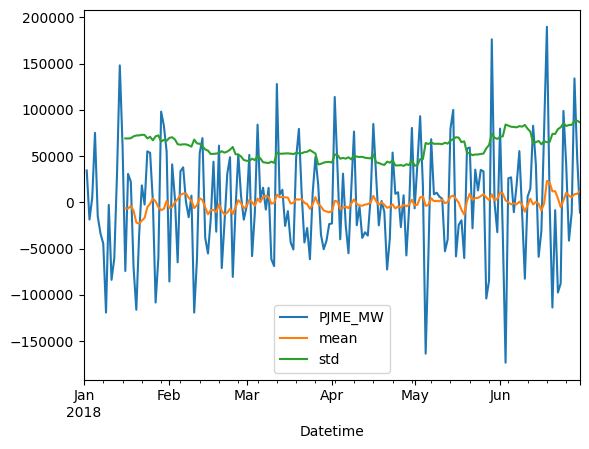

In [12]:
import pandas as pd

data = pd.read_csv('https://code.s3.yandex.net/datasets/energy_consumption.csv', index_col=[0], parse_dates=[0])
data.sort_index(inplace=True)
data = data['2018-01':'2018-06'].resample('1D').sum()
data = data - data.shift()
data['mean'] = data['PJME_MW'].rolling(15).mean()
data['std'] = data['PJME_MW'].rolling(15).std()
data.plot()
plt.show()

# Прогнозирование временных рядов

## Задача прогнозирования

Разбейте датасет о потреблении электроэнергии на обучающую и тестовую выборки в соотношении $4$:$1$.
Возьмите данные за доступное время.

Напечатайте на экране минимальные и максимальные значения индексов выборок (уже в прекоде).
Они нужны, чтобы убедиться в корректности деления.

In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split

data = pd.read_csv('https://code.s3.yandex.net/datasets/energy_consumption.csv', index_col=[0], parse_dates=[0])
data.sort_index(inplace=True)
data = data.resample('1D').sum()

train, test = train_test_split(data, shuffle=False, test_size=0.2)

print(train.index.min(), train.index.max())
print(test.index.min(), test.index.max())

2002-01-01 00:00:00 2015-04-09 00:00:00
2015-04-10 00:00:00 2018-08-03 00:00:00


## Качество прогноза

Спрогнозировать временные ряды без обучения можно двумя способами:
1. Все значения тестовой выборки предсказываются одним и тем же числом (константой). Для метрики MAE — это медиана.
2. Новое значение $x(t)$ прогнозируется предыдущим значением ряда, то есть $x(t-1)$. Этот способ не зависит от метрики.

1.
Оцените модель первым способом — прогнозом константой.
Дневной объём электропотребления предскажите медианой, сохраните значения в переменной `pred_median` и найдите для этого прогноза значение MAE.

В прекоде указан средний объём электропотребления, чтобы вы смогли соотнести его со значением метрики MAE.

Напечатайте на экране значения среднего объёма электропотребления и метрики MAE (уже в прекоде).

In [14]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

data = pd.read_csv('https://code.s3.yandex.net/datasets/energy_consumption.csv', index_col=[0], parse_dates=[0])
data.sort_index(inplace=True)
data = data.resample('1D').sum()

train, test = train_test_split(data, shuffle=False, test_size=0.2)

print("Средний объём электропотребления в день:", test['PJME_MW'].mean())

pred_median = pd.Series(train['PJME_MW'].median(), index=range(len(test)))
print("MAE:", mean_absolute_error(test['PJME_MW'], pred_median))

Средний объём электропотребления в день: 745523.4529702971
MAE: 96625.08333333333


2.
Оцените модель вторым способом — предыдущим значением ряда.
Предскажите дневной объём электропотребления и найдите для этого прогноза значение MAE.

В прекоде указан средний объём электропотребления, чтобы вы смогли соотнести его со значением метрики MAE.

Напечатайте на экране значения среднего объёма электропотребления и метрики MAE (уже в прекоде).

In [15]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

data = pd.read_csv('https://code.s3.yandex.net/datasets/energy_consumption.csv', index_col=[0], parse_dates=[0])
data.sort_index(inplace=True)
data = data.resample('1D').sum()

train, test = train_test_split(data, shuffle=False, test_size=0.2)

print("Средний объём электропотребления в день:", test['PJME_MW'].mean())

pred_previous = test['PJME_MW'].shift(1)
pred_previous.iloc[0] = train['PJME_MW'].iloc[-1]
print("MAE:", mean_absolute_error(test['PJME_MW'], pred_previous))

Средний объём электропотребления в день: 745523.4529702971
MAE: 44941.65924092409


##  Создание признаков

1.
Напишите функцию `make_features()` (англ. «создать признаки»),
чтобы прибавить к таблице четыре новых календарных признака: год, месяц, день и день недели.
Имена столбцов должны быть такие: `year`, `month`, `day`, `dayofweek`.

Примените функцию к таблице и напечатайте на экране её первые пять строк (уже в прекоде).

In [16]:
import pandas as pd
import numpy as np

data = pd.read_csv('https://code.s3.yandex.net/datasets/energy_consumption.csv', index_col=[0], parse_dates=[0])
data.sort_index(inplace=True)
data = data.resample('1D').sum()

def make_features(data):
    data['year'] = data.index.year
    data['month'] = data.index.month
    data['day'] = data.index.day
    data['dayofweek'] = data.index.dayofweek
    return data

make_features(data)
data.head()

,PJME_MW,year,month,day,dayofweek
Datetime,,,,,
2002-01-01,714857.0,2002,1,1,1
2002-01-02,822277.0,2002,1,2,2
2002-01-03,828285.0,2002,1,3,3
2002-01-04,809171.0,2002,1,4,4
2002-01-05,729723.0,2002,1,5,5


2.
Вычислите отстающие значения.
В функцию `make_features()` добавьте новый аргумент `max_lag`,
который задаст максимальный размер отставания.
Новые признаки назовите: `lag_1`, `lag_2` — и до величины `max_lag`.

Примените функцию к таблице и напечатайте на экране её первые пять строк (уже в прекоде).

In [17]:
import pandas as pd
import numpy as np

data = pd.read_csv('https://code.s3.yandex.net/datasets/energy_consumption.csv', index_col=[0], parse_dates=[0])
data.sort_index(inplace=True)
data = data.resample('1D').sum()

def make_features(data, max_lag):
    data['year'] = data.index.year
    data['month'] = data.index.month
    data['day'] = data.index.day
    data['dayofweek'] = data.index.dayofweek
    for lag in range(1, max_lag + 1):
        data[f'lag_{lag}'] = data['PJME_MW'].shift(lag)
    return data

make_features(data, 4)
data.head()

,PJME_MW,year,month,day,dayofweek,lag_1,lag_2,lag_3,lag_4
Datetime,,,,,,,,,
2002-01-01,714857.0,2002,1,1,1,NaN,NaN,NaN,NaN
2002-01-02,822277.0,2002,1,2,2,714857.0,NaN,NaN,NaN
2002-01-03,828285.0,2002,1,3,3,822277.0,714857.0,NaN,NaN
2002-01-04,809171.0,2002,1,4,4,828285.0,822277.0,714857.0,NaN
2002-01-05,729723.0,2002,1,5,5,809171.0,828285.0,822277.0,714857.0


3.
Вычислите скользящее среднее и добавьте его как признак `rolling_mean`.
В функцию `make_features()` добавьте новый аргумент `rolling_mean_size`, который задаст ширину окна. Текущее значение ряда для расчёта скользящего среднего применять нельзя.

Примените функцию к таблице и напечатайте на экране её первые пять строк (уже в прекоде).

In [18]:
import pandas as pd
import numpy as np

data = pd.read_csv('https://code.s3.yandex.net/datasets/energy_consumption.csv', index_col=[0], parse_dates=[0])
data.sort_index(inplace=True)
data = data.resample('1D').sum()

def make_features(data, max_lag, rolling_mean_size):
    data['year'] = data.index.year
    data['month'] = data.index.month
    data['day'] = data.index.day
    data['dayofweek'] = data.index.dayofweek
    for lag in range(1, max_lag + 1):
        data[f'lag_{lag}'] = data['PJME_MW'].shift(lag)
    data['rolling_mean'] = data['PJME_MW'].shift().rolling(rolling_mean_size).mean()
    return data

make_features(data, 4, 4)
data.head()

,PJME_MW,year,month,day,dayofweek,lag_1,lag_2,lag_3,lag_4,rolling_mean
Datetime,,,,,,,,,,
2002-01-01,714857.0,2002,1,1,1,NaN,NaN,NaN,NaN,NaN
2002-01-02,822277.0,2002,1,2,2,714857.0,NaN,NaN,NaN,NaN
2002-01-03,828285.0,2002,1,3,3,822277.0,714857.0,NaN,NaN,NaN
2002-01-04,809171.0,2002,1,4,4,828285.0,822277.0,714857.0,NaN,NaN
2002-01-05,729723.0,2002,1,5,5,809171.0,828285.0,822277.0,714857.0,793647.5


## Обучение модели

Обучим линейную регрессию с учётом новых признаков.

Разделим данные на обучающую и тестовую выборки.
Отстающие значения и скользящее среднее вычисляются по прошлым данным.
Признаки для первых значений тестовой выборки находятся в конце обучающей выборки.

Получить признаки для первых значений обучающей выборки нельзя: исторических данных по ним нет.
В предыдущих задачах значения этих признаков были `NaN`.
Их нужно удалить.

1.
Разбейте датасет о потреблении электроэнергии на обучающую и тестовую выборки в соотношении $4$:$1$.
Вам нужны данные за всё время.
Из обучающей выборки удалите строки с пропусками.

Напечатайте на экране размеры обучающей и тестовой выборки (уже в прекоде).

In [19]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

data = pd.read_csv('https://code.s3.yandex.net/datasets/energy_consumption.csv', index_col=[0], parse_dates=[0])
data.sort_index(inplace=True)
data = data.resample('1D').sum()

def make_features(data, max_lag, rolling_mean_size):
    data['year'] = data.index.year
    data['month'] = data.index.month
    data['day'] = data.index.day
    data['dayofweek'] = data.index.dayofweek
    for lag in range(1, max_lag + 1):
        data['lag_{}'.format(lag)] = data['PJME_MW'].shift(lag)
    data['rolling_mean'] = data['PJME_MW'].shift().rolling(rolling_mean_size).mean()

make_features(data, 1, 1)

train, test = train_test_split(data, shuffle=False, test_size=0.2)
train = train.dropna()

print(train.shape)
print(test.shape)

(4846, 7)
(1212, 7)


2.
В выборке выделите признаки и целевой признак.
На них обучите линейную регрессию и сохраните её в переменной `model`.
Затем напечатайте на экране значения MAE для обучающей и тестовой выборок (уже в прекоде).
Подберите аргументы функции `make_features()` так, чтобы значение MAE на тестовой выборке было не больше `37 000`.

In [20]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

data = pd.read_csv('https://code.s3.yandex.net/datasets/energy_consumption.csv', index_col=[0], parse_dates=[0])
data.sort_index(inplace=True)
data = data.resample('1D').sum()

def make_features(data, max_lag, rolling_mean_size):
    data['year'] = data.index.year
    data['month'] = data.index.month
    data['day'] = data.index.day
    data['dayofweek'] = data.index.dayofweek
    for lag in range(1, max_lag + 1):
        data['lag_{}'.format(lag)] = data['PJME_MW'].shift(lag)
    data['rolling_mean'] = data['PJME_MW'].shift().rolling(rolling_mean_size).mean()

make_features(data, 6, 3)

train, test = train_test_split(data, shuffle=False, test_size=0.2)
train = train.dropna()

features_train = train.drop('PJME_MW', axis=1)
target_train = train['PJME_MW']

features_test = test.drop('PJME_MW', axis=1)
target_test = test['PJME_MW']

model = LinearRegression()
model.fit(features_train, target_train)

predict_train = model.predict(features_train)
predict_test = model.predict(features_test)

print("MAE обучающей выборки:",  mean_absolute_error(target_train, predict_train))
print("MAE тестовой выборки: ",  mean_absolute_error(target_test, predict_test))

MAE обучающей выборки: 33613.67731523663
MAE тестовой выборки:  36794.85510988761
